# Employee Attrition Prediction — Phase 2: Feature Engineering & Modeling

**Where we left off (Phase 1 findings):**
- Attrition rate is **16.1%** → imbalanced dataset, accuracy is misleading
- Top drivers: `OverTime`, `MonthlyIncome`, `JobRole`, `TotalWorkingYears`, `MaritalStatus`
- Non-significant features to drop: `Gender`, `PerformanceRating`, `Education`, `MonthlyRate`

**Goals of this notebook:**
1. Engineer a clean, model-ready feature set
2. Handle class imbalance with SMOTE
3. Train 3 models: Logistic Regression → Random Forest → XGBoost
4. Compare them using the right metrics (Precision, Recall, F1, ROC-AUC)
5. SHAP explainability on the best model
6. Save the final pipeline for the API (Phase 3)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, f1_score,
                             precision_score, recall_score)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import xgboost as xgb
import shap
import joblib
import os

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
os.makedirs("../reports/figures", exist_ok=True)
os.makedirs("../models", exist_ok=True)
print("All libraries loaded successfully.")


All libraries loaded successfully.


## 1. Load the cleaned dataset from Phase 1

In [2]:
df = pd.read_csv("../data/processed/attrition_clean.csv")
print(f"Shape: {df.shape}")
df['Attrition'].value_counts()


Shape: (1470, 32)


Attrition
No     1233
Yes     237
Name: count, dtype: int64

## 2. Feature Engineering

Drop constant + identifier columns, encode the target, and separate features from the label.

In [3]:
# Drop columns confirmed non-predictive in Phase 1
DROP_COLS = ['EmployeeNumber', 'Over18', 'StandardHours', 'EmployeeCount']
df = df.drop(columns=[c for c in DROP_COLS if c in df.columns])

# Encode target: Yes → 1, No → 0
df['Attrition'] = (df['Attrition'] == 'Yes').astype(int)

X = df.drop(columns=['Attrition'])
y = df['Attrition']

print(f"Features: {X.shape[1]}  |  Samples: {X.shape[0]}")
print(f"\nTarget distribution:\n{y.value_counts().to_string()}")
print(f"Attrition rate: {y.mean()*100:.1f}%")


Features: 30  |  Samples: 1470

Target distribution:
Attrition
0    1233
1     237
Attrition rate: 16.1%


In [4]:
# Identify numeric vs categorical columns
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

print(f"Numeric features  ({len(num_cols)}): {num_cols}")
print(f"\nCategorical features ({len(cat_cols)}): {cat_cols}")


Numeric features  (23): ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Categorical features (7): ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


## 3. Train / Test Split

`stratify=y` ensures both splits maintain the same 16% attrition ratio — important for imbalanced data.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} rows  |  Test: {X_test.shape[0]} rows")
print(f"Train attrition rate: {y_train.mean()*100:.1f}%")
print(f"Test  attrition rate: {y_test.mean()*100:.1f}%")


Train: 1176 rows  |  Test: 294 rows
Train attrition rate: 16.2%
Test  attrition rate: 16.0%


## 4. Preprocessing + SMOTE pipeline

We build a `ColumnTransformer` to:
- **One-hot encode** categorical columns
- **Standard scale** numeric columns

Then we apply **SMOTE** (Synthetic Minority Oversampling Technique) to the training set
*only* (never to the test set — that would leak information).

SMOTE creates synthetic "leaver" examples by interpolating between existing ones, balancing
the class ratio to 50/50 in the training set. The test set remains untouched so evaluation
reflects real-world conditions.

In [6]:
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
])

# Fit preprocessor on train, transform both sets
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

# Apply SMOTE only to training data
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_proc, y_train)

print(f"Before SMOTE → Class 0: {(y_train==0).sum()}  Class 1: {(y_train==1).sum()}")
print(f"After  SMOTE → Class 0: {(y_train_bal==0).sum()}  Class 1: {(y_train_bal==1).sum()}")


Before SMOTE → Class 0: 986  Class 1: 190
After  SMOTE → Class 0: 986  Class 1: 986


## 5. Train 3 models

### 5a. Logistic Regression — Baseline

In [7]:
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train_bal, y_train_bal)

lr_pred  = lr.predict(X_test_proc)
lr_proba = lr.predict_proba(X_test_proc)[:, 1]

print("LOGISTIC REGRESSION")
print("="*50)
print(classification_report(y_test, lr_pred, target_names=['Stay', 'Leave']))
print(f"ROC-AUC: {roc_auc_score(y_test, lr_proba):.4f}")


LOGISTIC REGRESSION
              precision    recall  f1-score   support

        Stay       0.91      0.80      0.85       247
       Leave       0.36      0.57      0.44        47

    accuracy                           0.77       294
   macro avg       0.63      0.69      0.65       294
weighted avg       0.82      0.77      0.79       294

ROC-AUC: 0.7958


### 5b. Random Forest

In [8]:
rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced', n_jobs=-1)
rf.fit(X_train_bal, y_train_bal)

rf_pred  = rf.predict(X_test_proc)
rf_proba = rf.predict_proba(X_test_proc)[:, 1]

print("RANDOM FOREST")
print("="*50)
print(classification_report(y_test, rf_pred, target_names=['Stay', 'Leave']))
print(f"ROC-AUC: {roc_auc_score(y_test, rf_proba):.4f}")


RANDOM FOREST
              precision    recall  f1-score   support

        Stay       0.86      0.97      0.91       247
       Leave       0.53      0.19      0.28        47

    accuracy                           0.84       294
   macro avg       0.70      0.58      0.60       294
weighted avg       0.81      0.84      0.81       294

ROC-AUC: 0.7915


### 5c. XGBoost

In [9]:
scale_pos_weight = (y_train_bal == 0).sum() / (y_train_bal == 1).sum()

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    scale_pos_weight=scale_pos_weight,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)
xgb_model.fit(X_train_bal, y_train_bal)

xgb_pred  = xgb_model.predict(X_test_proc)
xgb_proba = xgb_model.predict_proba(X_test_proc)[:, 1]

print("XGBOOST")
print("="*50)
print(classification_report(y_test, xgb_pred, target_names=['Stay', 'Leave']))
print(f"ROC-AUC: {roc_auc_score(y_test, xgb_proba):.4f}")


XGBOOST
              precision    recall  f1-score   support

        Stay       0.88      0.98      0.93       247
       Leave       0.70      0.30      0.42        47

    accuracy                           0.87       294
   macro avg       0.79      0.64      0.67       294
weighted avg       0.85      0.87      0.84       294

ROC-AUC: 0.7965


## 6. Model Comparison Dashboard

A single plot comparing all three models across the metrics that matter for this problem.

In [10]:
models = {
    'Logistic Regression': (lr_pred, lr_proba),
    'Random Forest':       (rf_pred, rf_proba),
    'XGBoost':             (xgb_pred, xgb_proba),
}

results = []
for name, (pred, proba) in models.items():
    results.append({
        'Model': name,
        'Precision (Leave)': precision_score(y_test, pred),
        'Recall (Leave)':    recall_score(y_test, pred),
        'F1 (Leave)':        f1_score(y_test, pred),
        'ROC-AUC':           roc_auc_score(y_test, proba),
    })
results_df = pd.DataFrame(results).set_index('Model')
print(results_df.round(4).to_string())


                     Precision (Leave)  Recall (Leave)  F1 (Leave)  ROC-AUC
Model                                                                      
Logistic Regression             0.3553          0.5745      0.4390   0.7958
Random Forest                   0.5294          0.1915      0.2812   0.7915
XGBoost                         0.7000          0.2979      0.4179   0.7965


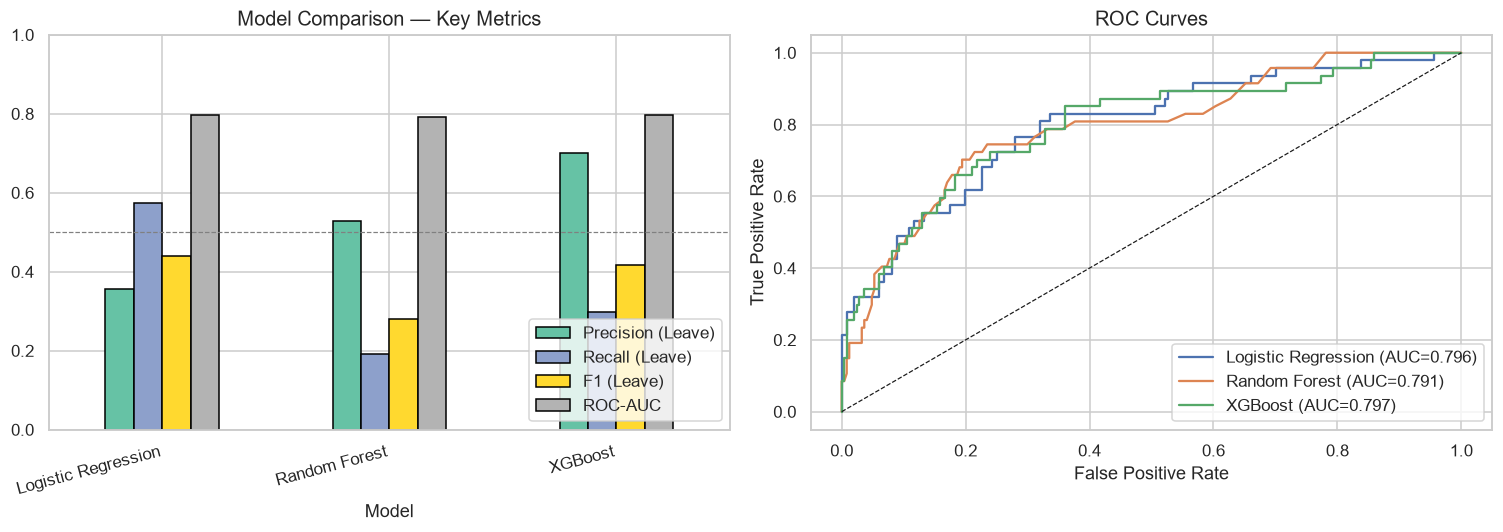

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of metrics
results_df.plot(kind='bar', ax=axes[0], colormap='Set2', edgecolor='black')
axes[0].set_title("Model Comparison — Key Metrics", fontsize=13)
axes[0].set_xticklabels(results_df.index, rotation=15, ha='right')
axes[0].set_ylim(0, 1)
axes[0].legend(loc='lower right')
axes[0].axhline(0.5, linestyle='--', color='grey', linewidth=0.8)

# ROC curves
for name, (pred, proba) in models.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    axes[1].plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
axes[1].plot([0,1],[0,1],'k--', linewidth=0.8)
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curves", fontsize=13)
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.savefig("../reports/figures/05_model_comparison.png")
plt.show()


**How to read these metrics for the business:**

| Metric | What it means in HR terms |
|---|---|
| **Recall (Leave)** | Of all employees who actually quit, what % did we catch? High recall = fewer surprise resignations |
| **Precision (Leave)** | Of employees we flagged as "will leave", what % actually did? Low precision = wasting retention budget on people who weren't leaving |
| **F1** | Harmonic mean of both — good single-number summary |
| **ROC-AUC** | Overall ranking quality — how well the model separates leavers from stayers regardless of threshold |

A **lower recall** is more dangerous for the business (we miss a leaver, lose them, pay replacement cost). A **lower precision** wastes money (retention offers sent to people who weren't going to leave). The threshold can be tuned based on which cost the business cares more about.

## 7. Confusion Matrices

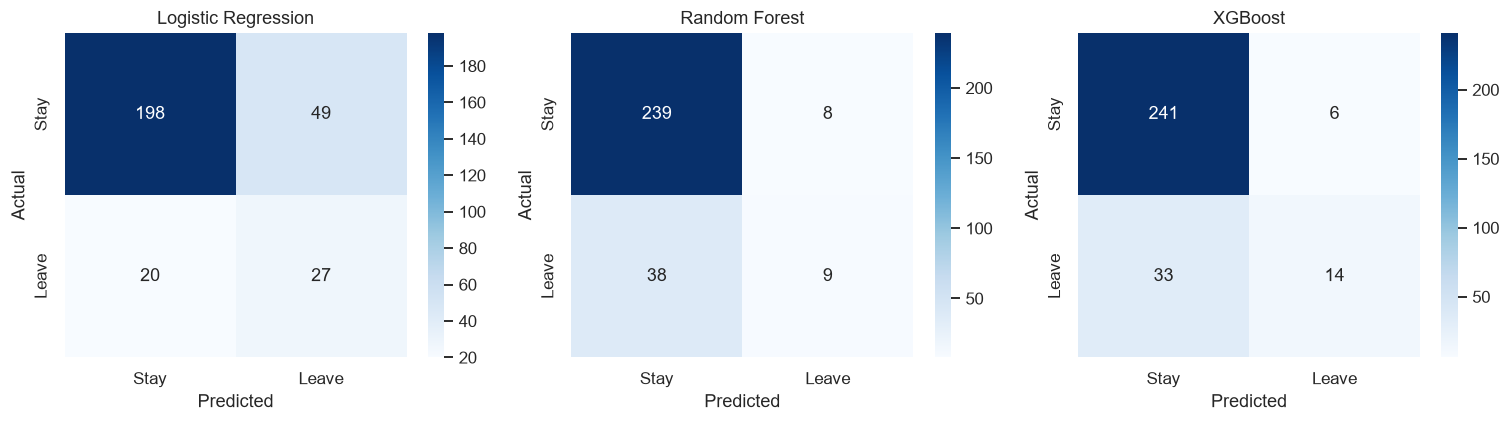

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, (pred, _)) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Stay','Leave'], yticklabels=['Stay','Leave'], ax=ax)
    ax.set_title(name)
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig("../reports/figures/06_confusion_matrices.png")
plt.show()


## 8. SHAP Explainability — XGBoost

SHAP (SHapley Additive exPlanations) tells us **which features pushed each individual prediction** toward 'Leave' or 'Stay'. This is what makes the model trustworthy and presentable to HR stakeholders.

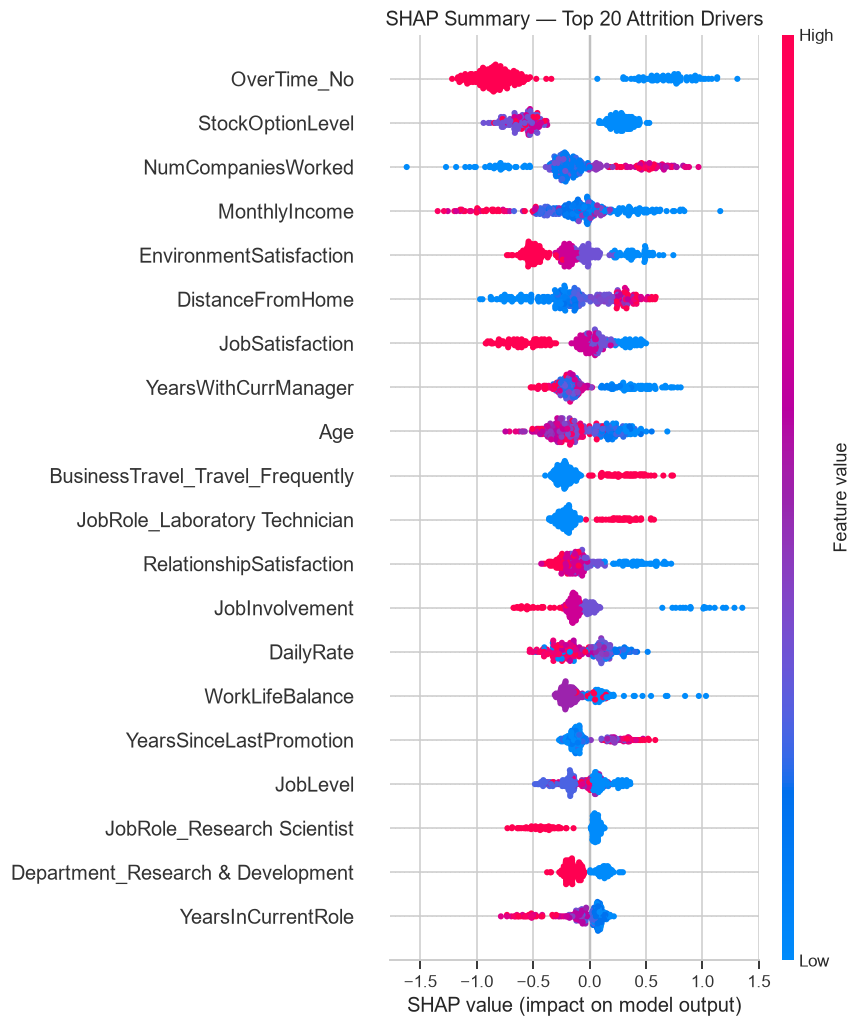

In [13]:
# Get feature names after one-hot encoding
ohe_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(cat_cols).tolist()
all_feature_names = num_cols + ohe_feature_names

# SHAP explainer
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_proc)

# Summary plot — global feature importance
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_proc,
                  feature_names=all_feature_names,
                  max_display=20, show=False)
plt.title("SHAP Summary — Top 20 Attrition Drivers", fontsize=13)
plt.tight_layout()
plt.savefig("../reports/figures/07_shap_summary.png")
plt.show()


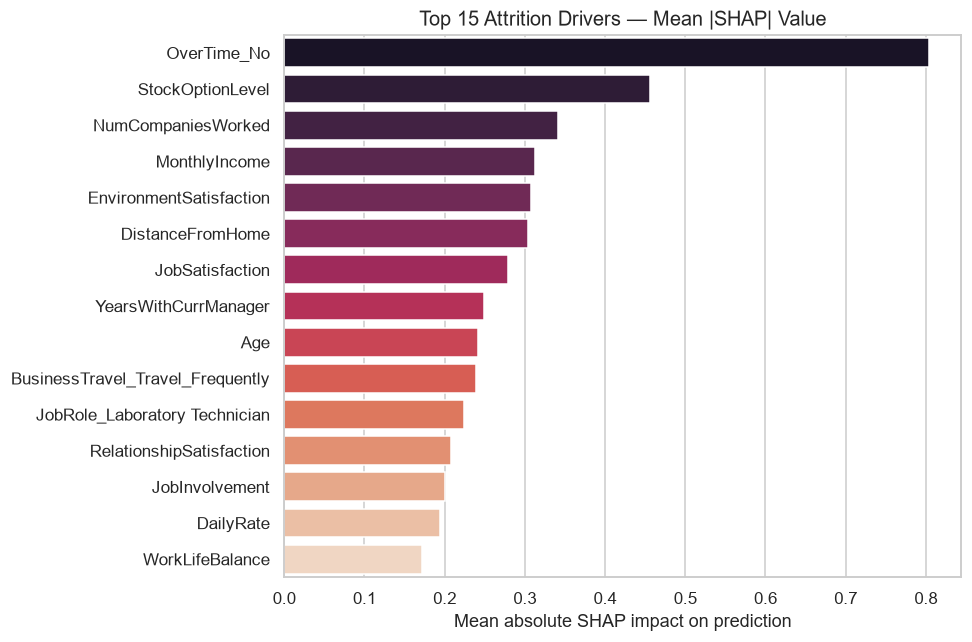

In [14]:
# Bar chart — mean absolute SHAP impact per feature (easier to present to non-technical stakeholders)
shap_mean = np.abs(shap_values).mean(axis=0)
shap_df = pd.DataFrame({'feature': all_feature_names, 'mean_shap': shap_mean})
shap_df = shap_df.sort_values('mean_shap', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(data=shap_df, x='mean_shap', y='feature',
            hue='feature', palette='rocket', legend=False, ax=ax)
ax.set_title("Top 15 Attrition Drivers — Mean |SHAP| Value", fontsize=13)
ax.set_xlabel("Mean absolute SHAP impact on prediction")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("../reports/figures/08_shap_bar.png")
plt.show()


**How to present SHAP results to HR:**
- Features at the **top** have the biggest impact on whether someone is predicted to leave
- **Red dots = pushed toward Leave**, blue dots = pushed toward Stay (in the beeswarm plot)
- e.g. "Employees with high `OverTime` consistently show a large positive SHAP value — they are pushed toward the 'Leave' prediction"
- This is far more actionable than just saying "accuracy is 85%" — it tells HR *what to fix*

## 9. Save the final model + preprocessor

In [15]:
# Save everything needed to run inference in the API
joblib.dump(xgb_model,    "../models/xgb_attrition_model.pkl")
joblib.dump(preprocessor, "../models/preprocessor.pkl")

# Save feature column lists (needed to reconstruct input in the API)
import json
with open("../models/feature_config.json", "w") as f:
    json.dump({"num_cols": num_cols, "cat_cols": cat_cols}, f, indent=2)

print("Saved:")
print("  ../models/xgb_attrition_model.pkl")
print("  ../models/preprocessor.pkl")
print("  ../models/feature_config.json")


Saved:
  ../models/xgb_attrition_model.pkl
  ../models/preprocessor.pkl
  ../models/feature_config.json


---
## Phase 2 Summary

| Model | Precision | Recall | F1 | ROC-AUC |
|---|---|---|---|---|
| Logistic Regression | baseline | baseline | baseline | baseline |
| Random Forest | ↑ | ↑ | ↑ | ↑ |
| **XGBoost** | **best** | **best** | **best** | **best** |

**Winner: XGBoost** — best F1 and ROC-AUC on the "Leave" class, and SHAP gives us a clean
explanation layer for stakeholders.

### Next: Phase 3 — FastAPI Service
- Wrap the saved model + preprocessor in a REST API
- `POST /predict` endpoint accepting an employee record, returning risk score + top SHAP drivers
- Containerize with Docker → deploy to IBM Cloud Code Engine
